The goal of this notebook is to see how the achieved sensitivity (kappa, L_E) varies with the real value of the parameter $p$. As shown below, lower values of $p$ achieve higher sensitivity.

In [1]:
from QSP_PE import QSP_PE
from single_iteration import QSP_single_iteration
import matplotlib.pyplot as plt
import numpy as np
from estimateP import estimate_p_bisect
from noise_signal_design import optimize_noise_sensitivity
from single_iteration import *

In [2]:
zero = np.array([1, 0], dtype=complex)
rho = np.outer(zero, zero.conj().T)

p_real = np.linspace(0.01, 0.1, 50)
p_prev = np.linspace(0.015, 0.15, 50)
dk = 8
C = 5
q = 2
rk_prev = np.linspace(0.01, 0.1, 50)
mk = 8000

In [8]:
def QSP_single_iteration_sensitivity_parameter(mk, C, dk, rk_prev, q, p_real, p_prev, rho):
    results_kappa = []
    results_L_E = []
    for i in range(50):
        theta, Phi, L_E, kappa = optimize_noise_sensitivity(d=dk, p_lo=p_prev[i]-rk_prev[i], p_hi=p_prev[i]+rk_prev[i])
        results_kappa.append(kappa)
        results_L_E.append(L_E)
    return results_kappa, results_L_E

kappa, L_E = QSP_single_iteration_sensitivity_parameter(mk=mk, C=C, dk=dk, rk_prev=rk_prev, q=q, p_real=p_real, p_prev=p_prev, rho=rho)

outer step   0  L_E = 13.0027  theta = 0.2666
outer step   1  L_E = 13.0027  theta = 0.2666
outer step   2  L_E = 13.0027  theta = 0.2666
outer step   3  L_E = 13.0027  theta = 0.2666
outer step   4  L_E = 13.0027  theta = 0.2666
outer step   5  L_E = 13.0027  theta = 0.2666
outer step   6  L_E = 13.0027  theta = 0.2666
outer step   7  L_E = 13.0027  theta = 0.2666
outer step   8  L_E = 13.0027  theta = 0.2666
outer step   9  L_E = 13.0027  theta = 0.2666
outer step  10  L_E = 13.0027  theta = 0.2666
outer step  11  L_E = 13.0027  theta = 0.2666
outer step  12  L_E = 13.0027  theta = 0.2666
outer step  13  L_E = 13.0027  theta = 0.2666
outer step  14  L_E = 13.0027  theta = 0.2666
outer step  15  L_E = 13.0027  theta = 0.2666
outer step  16  L_E = 13.0027  theta = 0.2666
outer step  17  L_E = 13.0027  theta = 0.2666
outer step  18  L_E = 13.0027  theta = 0.2666
outer step  19  L_E = 13.0027  theta = 0.2666
outer step   0  L_E = 11.6780  theta = 0.3027
outer step   1  L_E = 11.6780  the

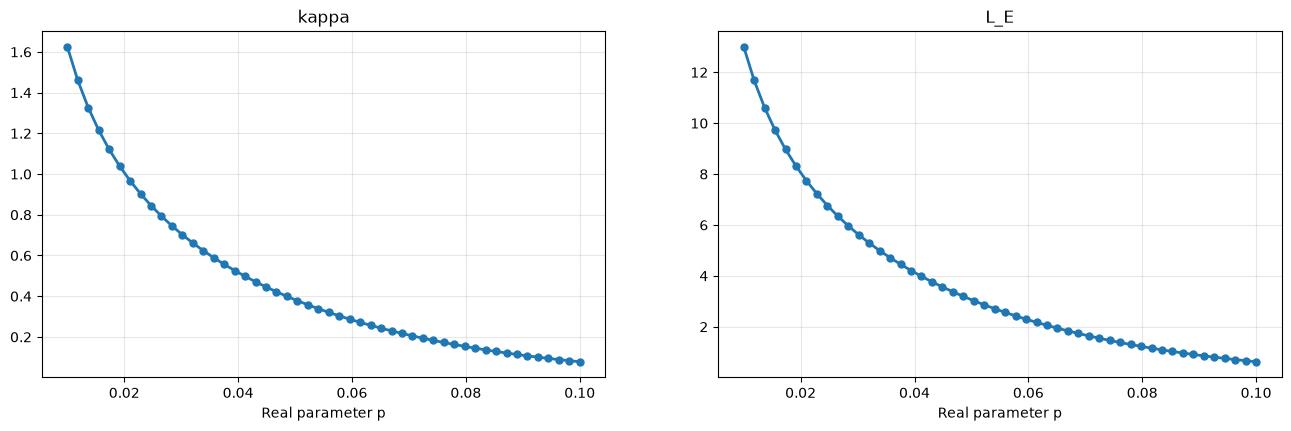

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4.5))
axs[0].plot(p_real, kappa, "o-", lw=2, markersize=5)
axs[0].set_xlabel('Real parameter p')
axs[0].set_title('kappa')
axs[0].grid(True, alpha=0.3)

axs[1].plot(p_real, L_E, "o-", lw=2, markersize=5)
axs[1].set_xlabel('Real parameter p')
axs[1].set_title('L_E')
axs[1].grid(True, alpha=0.3)

plt.show()